## Narcissus Poisoned

In [181]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/Narcissus/PoisonedGen.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

MODEL = 'HLB_S'

### Filter Data
df = df[df['Model'] == MODEL]

df_results = []
for data_key in df['Data Key'].unique():
    for eps in df['noise_eps_narcissus'].unique():
        df_filt = df[(df['Data Key'] == data_key) & (df['noise_eps_narcissus'] == eps)]

        if df_filt.empty: continue

        # Extract the defense name
        label = data_key.split('[')[0]

        if label == 'EBM': continue

        # Get Steps
        if label in ['DM_UNET']:
            steps = int(data_key.split('_T[')[1].split(']')[0])
            if eps == 8:
                if steps != 75: continue
            if eps == 16:
                if steps != 125: continue
        else:
            steps = int(data_key.split('Steps[')[1].split(']')[0])
            if eps == 8:
                if steps != 150: continue
            if eps == 16:
                if steps != 750: continue
            
        # Get Eps
        try:
            gen_eps = data_key.split('eps=')[1].split(']')[0]
        except:
            gen_eps = 0

        df_results.append({'Defense': 'PureEBM' if label == 'EBMSNGAN32' else 'PureDDPM',
                            'Steps': steps,
                            'Defense Str': f"PureEBM-{steps}" if label == 'EBMSNGAN32' else f"PureDDPM-{steps}",
                            'PureGen Eps': int(gen_eps),
                            'Eps': eps,
                            'Nat Acc': df_filt['End Acc'].mean(),
                            'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                            'Poison Success': df_filt['P1 Acc'].mean(),
                            'Poison Success Str': f"{df_filt['P1 Acc'].mean()*100:.2f}\u00B1{df_filt['P1 Acc'].std()*100:.2f}",
                            'Max Poison Success': df_filt['P1 Acc'].max(),
                            'Max Poison Success Str': f"{df_filt['P1 Acc'].max()*100:.2f}",
                            'Num Results': len(df_filt),
                        })

df_results = pd.DataFrame(df_results)
# df_results.sort_values(by=['Defense','Eps','PureGen Eps'], inplace=True)
df_results.pivot(index=['PureGen Eps','Defense'], columns='Eps', values=['Nat Acc Str', 'Poison Success Str', 'Max Poison Success Str'])

Nat Acc Str             Poison Success Str               \
Eps                           8           16                 8            16   
PureGen Eps Defense                                                            
0           PureDDPM  91.01±0.18  86.38±0.11          1.78±1.52    6.49±4.24   
            PureEBM   91.28±0.16  88.47±0.22          1.68±0.91    8.38±5.28   
8           PureDDPM  88.77±0.20  85.32±0.22          1.72±0.90    4.78±2.86   
            PureEBM   90.96±0.14  87.79±0.20         9.83±25.09    5.63±3.28   
16          PureDDPM  87.87±0.18  84.11±0.18          1.77±0.94    2.82±1.54   
            PureEBM   90.65±0.19  86.08±0.40          1.47±0.86  20.77±18.41   

                     Max Poison Success Str         
Eps                                      8      16  
PureGen Eps Defense                                 
0           PureDDPM                   5.52  14.00  
            PureEBM                    2.87  18.57  
8           PureDDPM                   3.06   9.80  
            PureEBM                   81.16  10.49  
16          PureDDPM                   3.07   5.78  
            PureEBM                    3.17  55.92

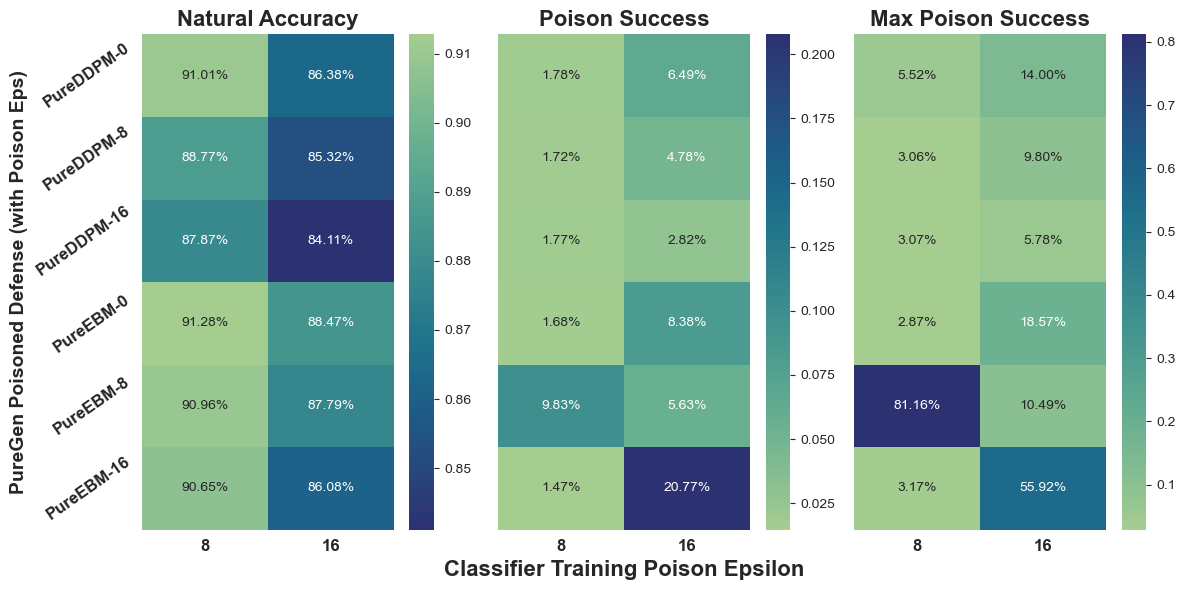

In [194]:
fig,axs = plt.subplots(1,3, figsize=(12,6))

sns.heatmap(df_results.pivot(index=['Defense','PureGen Eps'], columns='Eps', values='Nat Acc'), annot=True, fmt=".2%", cmap='crest_r', ax=axs[0])
# Format annot to be bold
axs[0].set_title('Natural Accuracy', fontsize=16, fontweight='bold')
axs[0].set_ylabel('PureGen Poisoned Defense (with Poison Eps)', fontsize=14, fontweight='bold')
axs[0].set_xlabel('')
# Rotate y tick labels
axs[0].set_yticklabels(axs[0].get_yticklabels(), rotation=35, fontsize=12, fontweight='bold')
axs[0].set_xticklabels(axs[0].get_xticklabels(), fontsize=12, fontweight='bold')


sns.heatmap(df_results.pivot(index=['Defense','PureGen Eps'], columns='Eps', values='Poison Success'), annot=True, fmt=".2%", cmap='crest', ax=axs[1])
axs[1].set_title('Poison Success', fontsize=16, fontweight='bold')
axs[1].set_ylabel('')
axs[1].set_xlabel('Classifier Training Poison Epsilon', fontsize=16, fontweight='bold')
axs[1].set_yticks([])
axs[1].set_xticklabels(axs[1].get_xticklabels(), fontsize=12, fontweight='bold')

sns.heatmap(df_results.pivot(index=['Defense','PureGen Eps'], columns='Eps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='crest', ax=axs[2])
axs[2].set_title('Max Poison Success', fontsize=16, fontweight='bold')
axs[2].set_ylabel('')
axs[2].set_xlabel('')
axs[2].set_yticks([])
axs[2].set_xticklabels(axs[2].get_xticklabels(), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'PoisonedGen.pdf', dpi=300,bbox_inches='tight')

## All Step Plots

In [124]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/Narcissus/PoisonedGen.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

EPS = 16
MODEL = 'HLB_S'

### Filter Data
df = df[df['noise_eps_narcissus'] == EPS]
df = df[df['Model'] == MODEL]

df_results = []
for data_key in df['Data Key'].unique():
    df_filt = df[df['Data Key'] == data_key]

    # Extract the defense name
    label = data_key.split('[')[0]

    if label == 'EBM': continue

    # Get Steps
    if label in ['DM_UNET']:
        steps = int(data_key.split('_T[')[1].split(']')[0])
    else:
        steps = int(data_key.split('Steps[')[1].split(']')[0])

    # Get Eps
    try:
        eps = data_key.split('eps=')[1].split(']')[0]
    except:
        eps = 0

    df_results.append({'Defense': 'PureEBM' if label == 'EBMSNGAN32' else 'PureDDPM',
                        'Steps': steps,
                        'Defense Str': f"PureEBM-{steps}" if label == 'EBMSNGAN32' else f"PureDDPM-{steps}",
                        'Eps': int(eps),
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                        'Poison Success': df_filt['P1 Acc'].mean(),
                        'Poison Success Str': f"{df_filt['P1 Acc'].mean()*100:.2f}\u00B1{df_filt['P1 Acc'].std()*100:.2f}",
                        'Max Poison Success': df_filt['P1 Acc'].max(),
                        'Max Poison Success Str': f"{df_filt['P1 Acc'].max()*100:.2f}",
                        'Num Results': len(df_filt),
                    })

df_results = pd.DataFrame(df_results)
df_results.sort_values(by=['Defense','Eps'], inplace=True)
df_results

,Defense,Steps,Defense Str,Eps,Nat Acc,Nat Acc Str,Poison Success,Poison Success Str,Max Poison Success,Max Poison Success Str,Num Results
3,PureDDPM,150,PureDDPM-150,0,0.84863,84.86%±0.18%,0.053308,5.33%±2.98%,0.113116,11.31%,10
4,PureDDPM,125,PureDDPM-125,0,0.86376,86.38%±0.11%,0.064890,6.49%±4.24%,0.140031,14.00%,10
5,PureDDPM,100,PureDDPM-100,0,0.87962,87.96%±0.17%,0.067989,6.80%±4.32%,0.139085,13.91%,10
6,PureDDPM,75,PureDDPM-75,0,0.89464,89.46%±0.19%,0.085271,8.53%±6.57%,0.210915,21.09%,10
7,PureDDPM,150,PureDDPM-150,8,0.83538,83.54%±0.16%,0.052346,5.23%±3.28%,0.108275,10.83%,10
8,PureDDPM,125,PureDDPM-125,8,0.85319,85.32%±0.22%,0.047755,4.78%±2.86%,0.097997,9.80%,10
9,PureDDPM,100,PureDDPM-100,8,0.87039,87.04%±0.31%,0.054934,5.49%±3.30%,0.104137,10.41%,10
10,PureDDPM,75,PureDDPM-75,8,0.88696,88.70%±0.21%,0.057817,5.78%±3.69%,0.120819,12.08%,10
11,PureDDPM,150,PureDDPM-150,16,0.82054,82.05%±0.15%,0.030282,3.03%±1.70%,0.062566,6.26%,10
12,PureDDPM,125,PureDDPM-125,16,0.84108,84.11%±0.18%,0.028206,2.82%±1.54%,0.057812,5.78%,10


/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_3958/4089261916.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_3958/4089261916.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])
/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_3958/4089261916.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[2].set_yticklabels(['{:,.1%}'.format(x) for x in axs[2].get_yticks()])


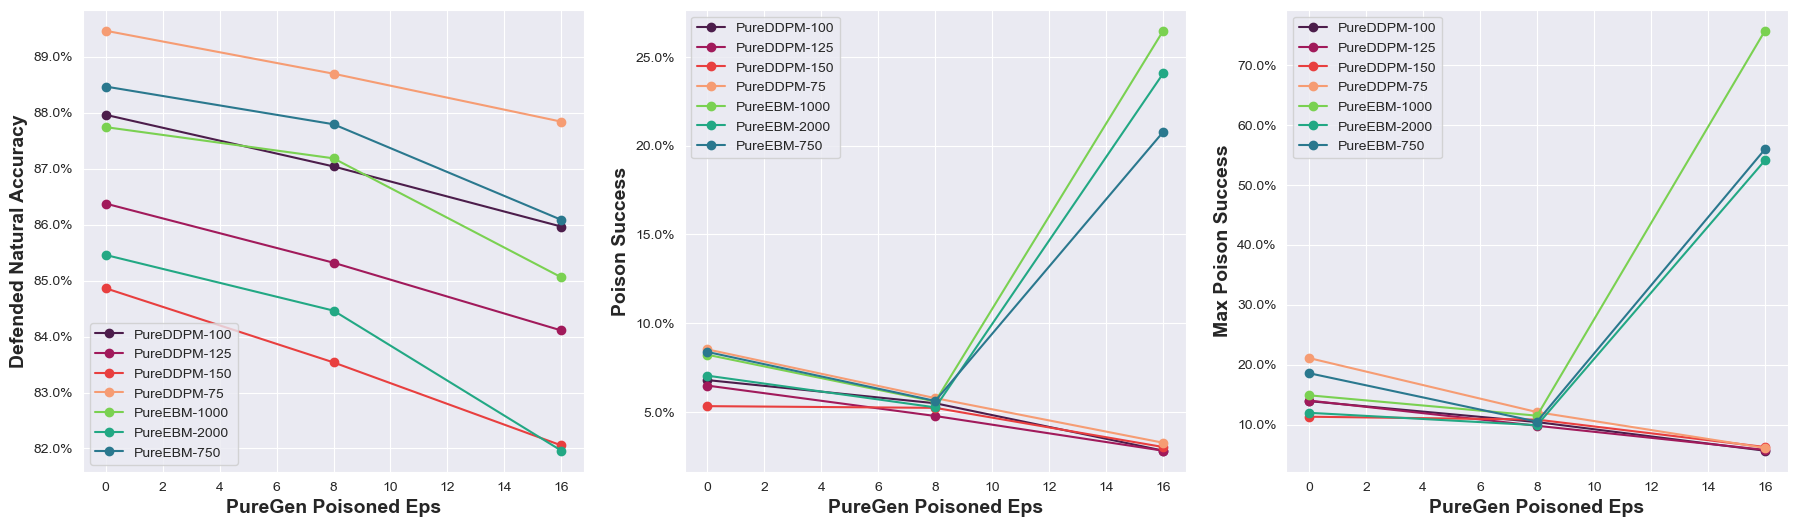

In [125]:

fig, axs = plt.subplots(1, 3, figsize=(22, 6))

# Natural Accuracy
pivot_table = df_results.pivot(index='Defense Str', columns='Eps', values='Nat Acc') 
cmap = sns.color_palette('rocket', 4) + sns.color_palette('viridis_r', 4)
for i, row in enumerate(pivot_table.iterrows()):
    index, values = row
    axs[0].plot(pivot_table.columns, values, marker='o', color=cmap[i], label=index)
axs[0].set_xlabel('PureGen Poisoned Eps', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Defended Natural Accuracy', fontsize=14, fontweight='bold')
axs[0].set_yticklabels(['{:,.1%}'.format(x) for x in axs[0].get_yticks()])
axs[0].legend()

# Poison Success
pivot_table = df_results.pivot(index='Defense Str', columns='Eps', values='Poison Success')
cmap = sns.color_palette('rocket', 4) + sns.color_palette('viridis_r', 4)
for i, row in enumerate(pivot_table.iterrows()):
    index, values = row
    axs[1].plot(pivot_table.columns, values, marker='o', color=cmap[i], label=index)

axs[1].set_xlabel('PureGen Poisoned Eps', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Poison Success', fontsize=14, fontweight='bold')
axs[1].set_yticklabels(['{:,.1%}'.format(x) for x in axs[1].get_yticks()])
axs[1].legend()

# Max Poison Success
pivot_table = df_results.pivot(index='Defense Str', columns='Eps', values='Max Poison Success')
cmap = sns.color_palette('rocket', 4) + sns.color_palette('viridis_r', 4)
for i, row in enumerate(pivot_table.iterrows()):
    index, values = row
    axs[2].plot(pivot_table.columns, values, marker='o', color=cmap[i], label=index)

axs[2].set_xlabel('PureGen Poisoned Eps', fontsize=14, fontweight='bold')
axs[2].set_ylabel('Max Poison Success', fontsize=14, fontweight='bold')
axs[2].set_yticklabels(['{:,.1%}'.format(x) for x in axs[2].get_yticks()])
axs[2].legend()

plt.savefig(f'PoisonedGen_Narc{EPS}_Steps.pdf', dpi=300,bbox_inches='tight')

In [44]:
dm_plot_diff

,Defense,Eps,Nat Acc,Nat Acc Str,Poison Success,Poison Success Str,Max Poison Success,Max Poison Success Str,Num Results,Label,Steps
0,EBMSNGAN32-2000,0,0.85458,85.46%±0.14%,0.070480,7.05%±3.55%,0.119630,11.96%,10,EBMSNGAN32,2000
1,EBMSNGAN32-1000,0,0.87742,87.74%±0.32%,0.082258,8.23%±4.64%,0.148812,14.88%,10,EBMSNGAN32,1000
2,EBMSNGAN32-750,0,0.88467,88.47%±0.22%,0.083831,8.38%±5.28%,0.185673,18.57%,10,EBMSNGAN32,750
3,DM_UNET-150,0,0.84863,84.86%±0.18%,0.053308,5.33%±2.98%,0.113116,11.31%,10,DM_UNET,150
4,DM_UNET-125,0,0.86376,86.38%±0.11%,0.064890,6.49%±4.24%,0.140031,14.00%,10,DM_UNET,125
5,DM_UNET-100,0,0.87962,87.96%±0.17%,0.067989,6.80%±4.32%,0.139085,13.91%,10,DM_UNET,100
6,DM_UNET-75,0,0.89464,89.46%±0.19%,0.085271,8.53%±6.57%,0.210915,21.09%,10,DM_UNET,75
7,DM_UNET-150,8,0.83538,83.54%±0.16%,0.052346,5.23%±3.28%,0.108275,10.83%,10,DM_UNET,150
8,DM_UNET-125,8,0.85319,85.32%±0.22%,0.047755,4.78%±2.86%,0.097997,9.80%,10,DM_UNET,125
9,DM_UNET-100,8,0.87039,87.04%±0.31%,0.054934,5.49%±3.30%,0.104137,10.41%,10,DM_UNET,100
